# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [50]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [51]:
salary_data = pd.read_csv("2025_salaries.csv", header=1, encoding='latin-1')
stats_data = pd.read_csv("nba_2025.txt", sep=",", encoding='latin-1')
salary_data.head()

,Player,Tm,2025-26
0,Jaden Springer,NOP,"$70,732"
1,Garrison Mathews,IND,"$131,970"
2,Garrison Mathews,IND,"$131,970"
3,Mac McClung,IND,"$164,060"
4,Didi Louzada,POR,"$268,032"


In [52]:
print(salary_data.shape)

(471, 3)


In [53]:
stats_data.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,1.0,Shai Gilgeous-Alexander,27.0,OKC,PG,49.0,49.0,1632.0,534.0,964.0,...,218.0,314.0,64.0,38.0,103.0,101.0,1558.0,0.0,NaN,gilgesh01
1,2.0,Tyrese Maxey,25.0,PHI,PG,52.0,52.0,2008.0,524.0,1117.0,...,214.0,351.0,102.0,40.0,126.0,118.0,1503.0,0.0,NaN,maxeyty01
2,3.0,Donovan Mitchell,29.0,CLE,SG,51.0,51.0,1719.0,516.0,1060.0,...,229.0,302.0,79.0,15.0,159.0,125.0,1478.0,0.0,NaN,mitchdo01
3,4.0,Jaylen Brown,29.0,BOS,SF,49.0,49.0,1676.0,534.0,1105.0,...,336.0,229.0,49.0,20.0,176.0,136.0,1435.0,2.0,NaN,brownja02
4,5.0,Luka DonÄiÄ,26.0,LAL,PG,42.0,42.0,1492.0,437.0,923.0,...,329.0,360.0,61.0,19.0,179.0,102.0,1379.0,6.0,NaN,doncilu01


In [54]:
print(stats_data.shape)

(643, 33)


In [55]:
merged_data = pd.merge(salary_data, stats_data, on='Player')
# merges the datasets salary_data and stats_data

In [56]:
merged_data.head()

,Player,Tm,2025-26,Rk,Age,Team,Pos,G,GS,MP,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,Garrison Mathews,IND,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
1,Garrison Mathews,IND,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
2,Mac McClung,IND,"$164,060",459.0,27.0,2TM,SG,4.0,0.0,47.0,...,5.0,2.0,5.0,2.0,3.0,8.0,23.0,0.0,NaN,mccluma01
3,Mac McClung,IND,"$164,060",459.0,27.0,IND,SG,3.0,0.0,34.0,...,4.0,1.0,5.0,1.0,2.0,6.0,19.0,0.0,NaN,mccluma01
4,Mac McClung,IND,"$164,060",459.0,27.0,CHI,SG,1.0,0.0,13.0,...,1.0,1.0,0.0,1.0,1.0,2.0,4.0,0.0,NaN,mccluma01


In [57]:
print(merged_data.columns)

Index(['Player', 'Tm', '2025-26', 'Rk', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP',
       'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'Trp-Dbl', 'Awards', 'Player-additional'],
      dtype='object')


In [64]:
# Task: Drop variables that will not be needed or are duplicates

merged_data = merged_data.drop(columns=['Team', 'Player-additional', 'Awards', 'Trp-Dbl','Rk', 'Tm_x'], errors='ignore')
# the code above removes the following columns from the merged_data dataset: 'Team', 'Player-additional', 
# 'Awards', 'Trp-Dbl''Rk', 'Tm_x'

merged_data = merged_data.rename(columns={'2025-26': 'Salary'})
# renames '2025-26' column to 'Salary'

merged_data = merged_data.drop_duplicates()
# eliminates rows that are entirely duplicate from dataset 


In [59]:
merged_data['Salary'] = merged_data['Salary'].replace(r'[\$,]', '', regex=True)
# removes the dollar signs and commas from the salary values
merged_data['Salary'] = merged_data['Salary'].astype(float)
# converts salary column from text to numeric 


In [60]:
print(merged_data.columns)
merged_data = merged_data.dropna()
# removes any rows that contain missing values (NaN) from merged_data datatset

Index(['Player', 'Tm', 'Salary', 'Age', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')


In [61]:
print(merged_data.shape)

(471, 30)


In [62]:
merged_data.head()

,Player,Tm,Salary,Age,Pos,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Garrison Mathews,IND,131970.0,29.0,SG,15.0,1.0,196.0,21.0,52.0,...,0.826,2.0,15.0,17.0,10.0,6.0,3.0,3.0,19.0,78.0
2,Mac McClung,IND,164060.0,27.0,SG,4.0,0.0,47.0,9.0,25.0,...,0.750,0.0,5.0,5.0,2.0,5.0,2.0,3.0,8.0,23.0
3,Mac McClung,IND,164060.0,27.0,SG,3.0,0.0,34.0,7.0,18.0,...,0.750,0.0,4.0,4.0,1.0,5.0,1.0,2.0,6.0,19.0
5,Monte Morris,IND,321184.0,30.0,PG,6.0,0.0,65.0,7.0,20.0,...,0.500,1.0,6.0,7.0,9.0,1.0,1.0,2.0,3.0,18.0
6,E.J. Liddell,PHO,706898.0,25.0,PF,10.0,0.0,49.0,8.0,17.0,...,0.667,3.0,8.0,11.0,0.0,1.0,0.0,0.0,4.0,22.0


In [63]:
print(merged_data)

               Player   Tm      Salary   Age Pos     G    GS      MP     FG  \
0    Garrison Mathews  IND    131970.0  29.0  SG  15.0   1.0   196.0   21.0   
2         Mac McClung  IND    164060.0  27.0  SG   4.0   0.0    47.0    9.0   
3         Mac McClung  IND    164060.0  27.0  SG   3.0   0.0    34.0    7.0   
5        Monte Morris  IND    321184.0  30.0  PG   6.0   0.0    65.0    7.0   
6        E.J. Liddell  PHO    706898.0  25.0  PF  10.0   0.0    49.0    8.0   
..                ...  ...         ...   ...  ..   ...   ...     ...    ...   
509      Kevin Durant  HOU  54708609.0  37.0  SF  50.0  50.0  1835.0  452.0   
510       Joel Embiid  PHI  55224526.0  31.0   C  31.0  31.0   972.0  278.0   
511      Bradley Beal  LAC  59020270.0  32.0  SG   6.0   6.0   121.0   18.0   
512      Bradley Beal  PHO  59020270.0  32.0  SG   6.0   6.0   121.0   18.0   
513     Stephen Curry  GSW  59606817.0  37.0  PG  39.0  39.0  1222.0  348.0   

       FGA  ...    FT%   ORB    DRB    TRB    AST  

In [66]:
#Task: Run the clustering algo with your best guess for K

player_info = merged_data[['Player', 'Tm', 'Salary']]
# creates a dataframe with just the Player, Team, and Salary columns because 
# clustering cannot use text columns

performance_vars = merged_data.drop(columns=['Player', 'Tm', 'Salary', 'Pos'], errors='ignore')
# creates a second dataframe containing only the numerical performance statistics 
# by eliminating the Player, Teams, Salary, and Position column

In [67]:
scaler = StandardScaler()
# creates a StandardScaler object from sklearn.preprocessing; StandardScalar is used 
# to standardize numerical data

scaled_data = scaler.fit_transform(performance_vars)
# fit() function the scaler learns the mean and standard deviation of each column and rescales every value
# this is important because KMeans uses distance calculations 

In [68]:
k = 5  
# creates a clustering model of 5 clusters based on performance statistics

kmeans = KMeans(n_clusters = k, random_state = 42)
# creates the KMeans clustering model

merged_data['Cluster'] = kmeans.fit_predict(scaled_data)
# model learns the clusters by looking at the scaled performance data
# finds centroids that minimize distance between players and the
# center of these clusters 

In [70]:
cluster_summary = merged_data.groupby('Cluster')['Salary'].mean().sort_values()
# groups the dataset based on cluster labels declared by KMeans
# the salary column is selected within each cluster and the mean calculates the average
# salary for each cluster
# the salary values are sorted fro lowest to highest

print(cluster_summary)

Cluster
1    7.469205e+06
2    9.635443e+06
3    1.139939e+07
0    1.704795e+07
4    3.298551e+07
Name: Salary, dtype: float64


In [71]:
#Task: View the results
merged_data.head()

,Player,Tm,Salary,Age,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Cluster
0,Garrison Mathews,IND,131970.0,29.0,SG,15.0,1.0,196.0,21.0,52.0,...,2.0,15.0,17.0,10.0,6.0,3.0,3.0,19.0,78.0,1
2,Mac McClung,IND,164060.0,27.0,SG,4.0,0.0,47.0,9.0,25.0,...,0.0,5.0,5.0,2.0,5.0,2.0,3.0,8.0,23.0,1
3,Mac McClung,IND,164060.0,27.0,SG,3.0,0.0,34.0,7.0,18.0,...,0.0,4.0,4.0,1.0,5.0,1.0,2.0,6.0,19.0,1
5,Monte Morris,IND,321184.0,30.0,PG,6.0,0.0,65.0,7.0,20.0,...,1.0,6.0,7.0,9.0,1.0,1.0,2.0,3.0,18.0,1
6,E.J. Liddell,PHO,706898.0,25.0,PF,10.0,0.0,49.0,8.0,17.0,...,3.0,8.0,11.0,0.0,1.0,0.0,0.0,4.0,22.0,1


In [75]:
merged_data[merged_data['Player'] == 'Mac McClung']

,Player,Tm,Salary,Age,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Cluster
2,Mac McClung,IND,164060.0,27.0,SG,4.0,0.0,47.0,9.0,25.0,...,0.0,5.0,5.0,2.0,5.0,2.0,3.0,8.0,23.0,1
3,Mac McClung,IND,164060.0,27.0,SG,3.0,0.0,34.0,7.0,18.0,...,0.0,4.0,4.0,1.0,5.0,1.0,2.0,6.0,19.0,1


In [77]:
merged_data['Cluster'].value_counts()
# number of players per cluster group

#

Cluster
1    157
2    139
0     93
3     46
4     36
Name: count, dtype: int64

In [78]:
merged_data.groupby('Cluster')['Salary'].mean().sort_values()
# groups all the rows of merged_data on the cluster label assigned by KMeans 
# calculates the average salary of the players in respective cluster
# then sorts cluster from lowest to highest average salary

Cluster
1    7.469205e+06
2    9.635443e+06
3    1.139939e+07
0    1.704795e+07
4    3.298551e+07
Name: Salary, dtype: float64

In [ ]:
#Task: Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

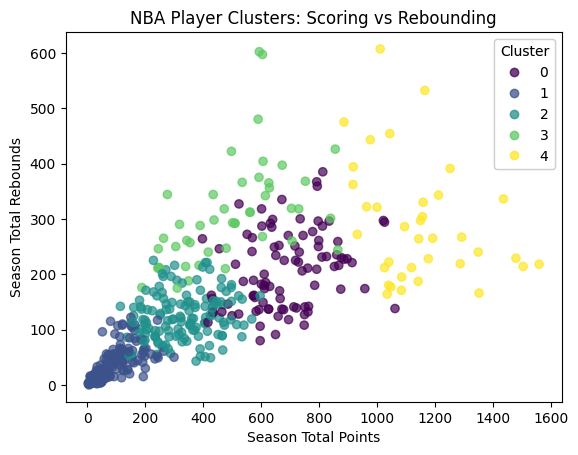

In [85]:
# figure A (Points Per Game vs Total Rebounds Per Game) with a legend
scatter = plt.scatter(merged_data['PTS'], merged_data['TRB'], c=merged_data['Cluster'], alpha=0.7)

plt.xlabel("Season Total Points")
plt.ylabel("Season Total Rebounds")
plt.title("NBA Player Clusters: Scoring vs Rebounding")


legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()

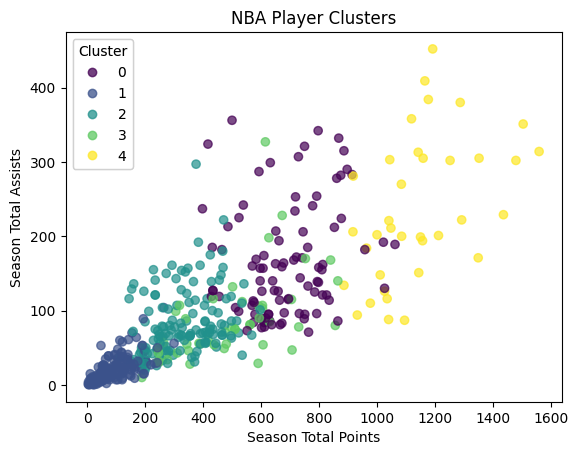

In [86]:
# figure B (Points Per Game vs Assists Per Game) with a legend

scatter = plt.scatter(
    merged_data['PTS'],
    merged_data['AST'],
    c=merged_data['Cluster'],
    alpha=0.7
)

plt.xlabel("Season Total Points")
plt.ylabel("Season Total Assists")
plt.title("NBA Player Clusters")

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()


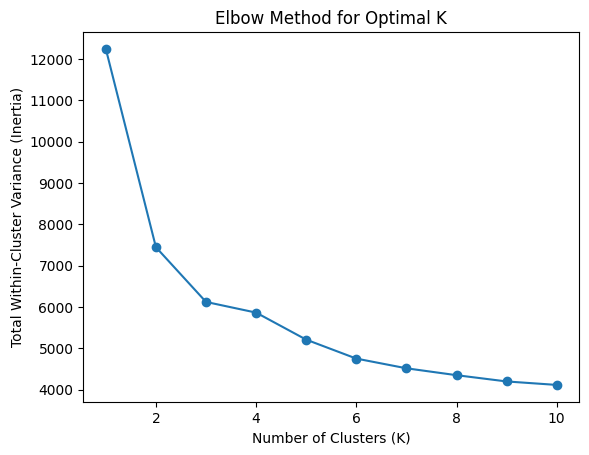

In [82]:
#Task: Evaluate the quality of the clustering using total variance explained and silhouette scores

inertia = []
#stores the total within-cluster variables from each value of K

K_range = range(1, 11)
#tests 1 through 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
#for each KMeans cluster ran, computes inertia (the distance between each data point and its cluster center)

#plotting the elbow curve
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Total Within-Cluster Variance (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

In [83]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, merged_data['Cluster'])
# computes silhouette score using scaled_data (data with the standardized performance stats)
# analyzes the features and cluster labels and evaluates how well seperated the clusters are
print("Silhouette Score:", score)

Silhouette Score: 0.1742717315791972


In [89]:
# Evaluation: The elbow method is used when finding the ideal number of clusters 
# by examining how total within-cluster variance as K increases. We could see through
# the figures that there is a large reduction in variance between K = 1 and K = 2, which tells us 
# that overall data structures can be represented using a small number of clusters. Silhouette scors were 
# also calculated, the highest score being 0.327 at K = 2, which signifies a relatively distinct
# cluster separation. We can see an inverse relationship bnetween silhouette score and cluster 
# effectiveness -- as you increase K, the clusters becoe less distinct. 

In [90]:
#Task: Determine the ideal number of clusters using the elbow method and the silhouette coefficient
K_range = range(2, 11)
# defines the range of cluster values 

inertia = []
silhouette_scores = []
# the initializers create empty lists for results 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))
# loops through possible k values. The clustering model is run once for each value within K.
# a clustering model is created and is fitted and assigned cluster labels 
# store inertia and silouette score 

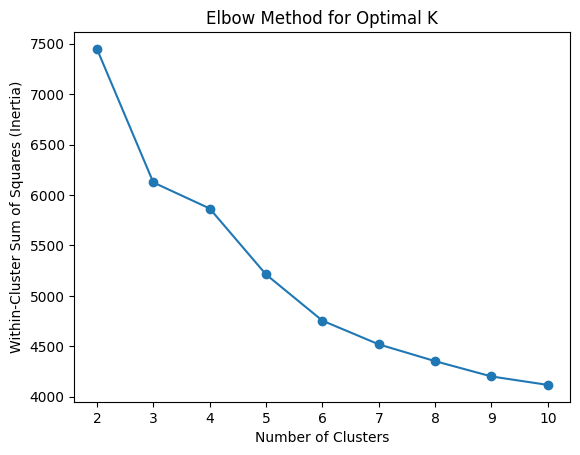

In [92]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

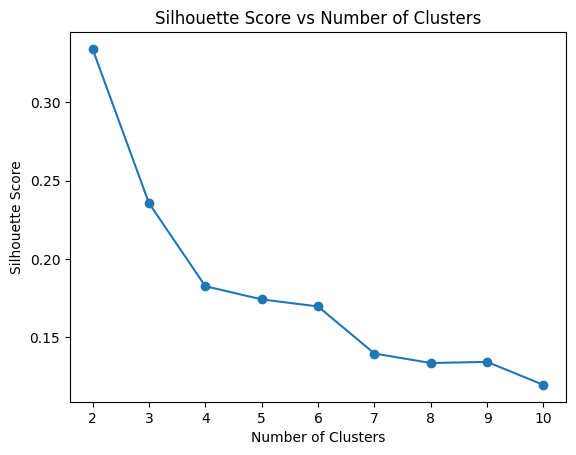

In [93]:
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

In [95]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.3f}")

# pairs two lists (K_range and silhouette_scores) then loops through each pair

K = 2, Silhouette Score = 0.334
K = 3, Silhouette Score = 0.236
K = 4, Silhouette Score = 0.183
K = 5, Silhouette Score = 0.174
K = 6, Silhouette Score = 0.170
K = 7, Silhouette Score = 0.140
K = 8, Silhouette Score = 0.134
K = 9, Silhouette Score = 0.134
K = 10, Silhouette Score = 0.120


In [96]:
# Evaluation: The elbow method was utilized in order to evaluate the total in-cluster variance
# We can see from the visualizations that there is a significant decrease in variance fro K = 1
# to K = 2 and we can see a smaller decrease when K = 3 or 4. This means that after that point,
# improvements did not make that much of a difference in value, leading us to believe the optimal number 
# of clusters is 3 or 4. Silhouette scores was another metric used to calculate how well playyers fit
# within clusters. The highest score was at K = 2, which was a score of 0.327. This tells us that there is moderate
# separation between clusters. At K = 2, the score is 0.176 -- which means the clusters do in fact exist,
# but it is less clearly sperated, especially when more clusters are added. This demonstrates that the overlap present
# in player skills makes creating distinct clusters and having perfect separation difficult.


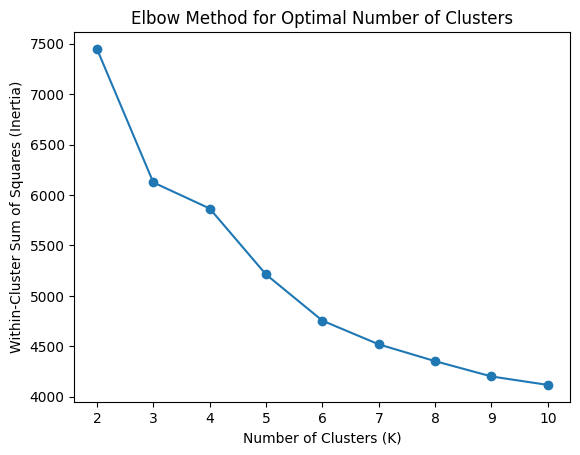

In [97]:
#Task: Visualize the results of the elbow method

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

In [98]:
print(K_range)
print(inertia)

range(2, 11)
[7448.853133185553, 6125.043452176686, 5866.670797294735, 5212.507493146446, 4754.643162420001, 4519.722299448412, 4353.115175869019, 4201.488975378035, 4117.5299281906455]


In [103]:
# Task: Use the recommended number of cluster (assuming it's different) to retrain your 
# model and visualize the results


optimal_k = 4  
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
# creates a new clustering model using 4 clusters
merged_data['Cluster'] = kmeans.fit_predict(scaled_data)
# fits model into the scaled player performance data and assins player to a cluster


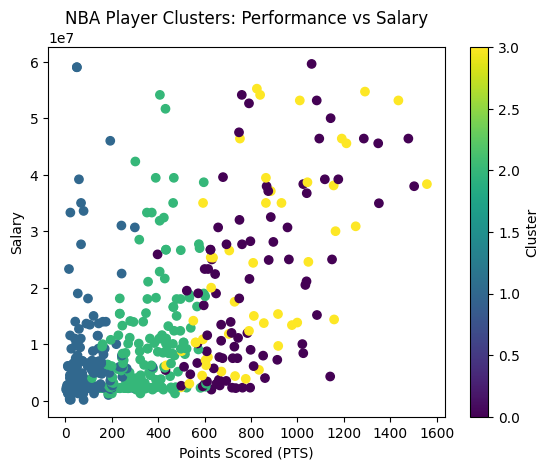

In [104]:
scatter = plt.scatter(merged_data['PTS'], merged_data['Salary'], c=merged_data['Cluster'])

plt.xlabel("Points Scored (PTS)")
plt.ylabel("Salary")
plt.title("NBA Player Clusters: Performance vs Salary")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [105]:
#Task: Once again evaluate the quality of the clustering using total variance explained 
#and silhouette scores

total_variance = kmeans.inertia_
print("Total Within-Cluster Variance (Inertia):", total_variance)

sil_score = silhouette_score(scaled_data, merged_data['Cluster'])
print("Silhouette Score:", sil_score)


Total Within-Cluster Variance (Inertia): 5866.670797294735
Silhouette Score: 0.1827184612327357


In [106]:
# Evaluation: We know that the highest silouette score happened at K = 2 (0.334), which means
# there is a moderately strong seperation between clusters. K = 4 was selected to balance cluster 
# seperations with the hopes of increasing interpretability. This model has a silhouette
# score of 0.183 and an inertia value of 5866.67, which further enforces this moderate separation
# between clusters. This means a lot of NBA players have overlapping performance records and similar profiles.

In [107]:
cluster_summary = merged_data.groupby('Cluster')[['Salary', 'PTS', 'AST', 'TRB', 'MP']].mean()
# groups the dataset by cluster number and selects specific columns we want to analyze. Calculates the average value
# for each stat within each cluster
print(cluster_summary)

               Salary         PTS         AST         TRB           MP
Cluster                                                               
0        2.050592e+07  806.093023  187.790698  210.209302  1440.965116
1        7.342098e+06   95.496970   22.690909   38.496970   255.103030
2        9.850306e+06  355.570588   85.276471  147.047059   872.176471
3        2.319587e+07  836.600000  163.260000  350.760000  1465.760000


In [111]:
# evaluates good players who score a lot but get paid less
good_targets = merged_data.sort_values(
    by=['PTS', 'Salary'],
    ascending=[False, True]
)[['Player','Tm','Salary','PTS','AST','TRB','Cluster']]
# sorting points and salary so the highest points are first and the lowest salaries are also first
# cheaper salaries are first and the columns for display have been selected
good_targets.head(10)

,Player,Tm,Salary,PTS,AST,TRB,Cluster
478,Shai Gilgeous-Alexander,OKC,38333050.0,1558.0,314.0,218.0,3
475,Tyrese Maxey,PHI,37958760.0,1503.0,351.0,214.0,0
494,Donovan Mitchell,CLE,46394100.0,1478.0,302.0,229.0,0
505,Jaylen Brown,BOS,53142264.0,1435.0,229.0,336.0,3
465,Jalen Brunson,NYK,34944001.0,1351.0,305.0,166.0,0
492,Anthony Edwards,MIN,45550512.0,1348.0,171.0,240.0,0
509,Kevin Durant,HOU,54708609.0,1291.0,222.0,267.0,3
496,Jamal Murray,DEN,46394100.0,1286.0,380.0,219.0,0
455,Julius Randle,MIN,30864198.0,1251.0,302.0,391.0,3
491,Pascal Siakam,IND,45550512.0,1211.0,201.0,343.0,3


In [112]:
# evaluates not so good players who score little for how much money the make

notgreat_players = merged_data.sort_values(
    by=['Salary','PTS'],
    ascending=[False, True]
)[['Player','Tm','Salary','PTS','AST','TRB','Cluster']]
# sorting points and salary so the lowest points are first and the high salaries are also first
# cheaper salaries are first and the columns for display have been selected
notgreat_players.head(10)

,Player,Tm,Salary,PTS,AST,TRB,Cluster
513,Stephen Curry,GSW,59606817.0,1061.0,189.0,138.0,0
511,Bradley Beal,LAC,59020270.0,49.0,10.0,5.0,1
512,Bradley Beal,PHO,59020270.0,49.0,10.0,5.0,1
510,Joel Embiid,PHI,55224526.0,825.0,121.0,232.0,3
509,Kevin Durant,HOU,54708609.0,1291.0,222.0,267.0,3
508,Anthony Davis,WAS,54126450.0,407.0,56.0,221.0,2
506,Jimmy Butler,GSW,54126450.0,760.0,185.0,211.0,0
507,Giannis Antetokounmpo,MIL,54126450.0,839.0,168.0,301.0,3
503,Karl-Anthony Towns,NYK,53142264.0,1010.0,148.0,607.0,3
504,Devin Booker,PHO,53142264.0,1083.0,270.0,171.0,0


In [113]:
# evaluates players that could be beneficial but not amazing 
backup_players = merged_data.sort_values(
    by=['PTS','Salary'],
    ascending=[False, False]
)[['Player','Tm','Salary','PTS','AST','TRB','Cluster']]
#finds players who score the least but earn the most 

backup_players.head(10)

,Player,Tm,Salary,PTS,AST,TRB,Cluster
478,Shai Gilgeous-Alexander,OKC,38333050.0,1558.0,314.0,218.0,3
475,Tyrese Maxey,PHI,37958760.0,1503.0,351.0,214.0,0
494,Donovan Mitchell,CLE,46394100.0,1478.0,302.0,229.0,0
505,Jaylen Brown,BOS,53142264.0,1435.0,229.0,336.0,3
465,Jalen Brunson,NYK,34944001.0,1351.0,305.0,166.0,0
492,Anthony Edwards,MIN,45550512.0,1348.0,171.0,240.0,0
509,Kevin Durant,HOU,54708609.0,1291.0,222.0,267.0,3
496,Jamal Murray,DEN,46394100.0,1286.0,380.0,219.0,0
455,Julius Randle,MIN,30864198.0,1251.0,302.0,391.0,3
491,Pascal Siakam,IND,45550512.0,1211.0,201.0,343.0,3


In [114]:
# Good choices: Players under this category are strong athletes -- they score well 
# and are being paid less than their counterparts. Some players who meet these requirements 
# include Shai Gilgeous-Alexander, Tyrese Maxey, Donovan Mitchell, and Jaylen Brown. They would be 
# best for my team as they score pretty high (Shai Gilgeous-Alexander scored 1558.0) while recieving relativel low salaries
# (Gilgeous-Alexander's salary is $38,333,050.0).

# Bad choices: These players have high salaries but low performance stats. Their numbers are not 
# that much better than lower-paid players. Some players who meet these requirements are Stephen Curry, 
# Joel Embiid, Bradley Beal, Kevin Durant.

# Backup choices: These players have reasonable salaries, but are a bit more than the best value
# players. They are still valid and great options, if the good choices are no longer available. Players
# would meet these requirements are Anthony Edwards, Jamal Murray, Julius Randle, Pascal Siakam.

In [115]:
# Task: Write up the results in a separate notebook with supporting visualizations and 
# an overview of how and why you made the choices you did. This should be at least 
# 500 words and should be written for a non-technical audience.